# Data Pre-Processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Create Dataframe
df = pd.read_csv('Data\data.csv')
# Print shape of dataset
print(df.shape)

(75083, 11)


## Data Cleaning

### Handling Missing values

* Handling Missing values 
* Handling Duplicates
* Check data type
* Understand the dataset

In [2]:
df.isnull().sum()

DATE                0
VISIBILITY          0
DRYBULBTEMPF        0
WETBULBTEMPF        0
DewPointTempF       0
RelativeHumidity    0
WindSpeed           0
WindDirection       0
StationPressure     0
SeaLevelPressure    0
Precip              0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

**Drop the columns which we could see in the EDA notebook are not either important or having high correlation**

In [4]:
df=df.drop(['WETBULBTEMPF','DewPointTempF','StationPressure'],axis=1)

In [5]:
df

,DATE,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,Precip
0,2010-01-01 00:51:00,6.0,33,92,0,0,29.99,0.01
1,2010-01-01 01:51:00,6.0,33,96,0,0,29.99,0.02
2,2010-01-01 02:51:00,5.0,33,96,0,0,29.99,0.02
3,2010-01-01 03:51:00,5.0,33,96,0,0,29.97,0.02
4,2010-01-01 04:51:00,5.0,33,92,0,0,29.96,0.02
...,...,...,...,...,...,...,...,...
75078,2018-07-27 18:51:00,10.0,76,88,3,230,30.02,0.00
75079,2018-07-27 19:51:00,4.0,69,100,13,40,30.01,1.16
75080,2018-07-27 20:51:00,10.0,71,96,0,0,30.04,0.01
75081,2018-07-27 21:51:00,10.0,72,94,5,50,30.02,0.01


In [6]:
df=df.drop(['DATE','Precip'],axis=1)

In [7]:
df

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure
0,6.0,33,92,0,0,29.99
1,6.0,33,96,0,0,29.99
2,5.0,33,96,0,0,29.99
3,5.0,33,96,0,0,29.97
4,5.0,33,92,0,0,29.96
...,...,...,...,...,...,...
75078,10.0,76,88,3,230,30.02
75079,4.0,69,100,13,40,30.01
75080,10.0,71,96,0,0,30.04
75081,10.0,72,94,5,50,30.02


In [8]:
num_feature=[feature for feature in df.columns if df[feature].dtype!='O']

In [9]:
num_feature

['VISIBILITY',
 'DRYBULBTEMPF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'SeaLevelPressure']

In [10]:
cat_feature=[feature for feature in df.columns if df[feature].dtype=='O']

In [11]:
cat_feature

[]

In [12]:
discrete_features=[feature for feature in num_feature if len(df[feature].unique())<=25]

In [13]:
discrete_features

['VISIBILITY']

**Continues Features**

In [14]:
continuous_feature=[feature for feature in num_feature if feature not in discrete_features]

In [15]:
continuous_feature

['DRYBULBTEMPF',
 'RelativeHumidity',
 'WindSpeed',
 'WindDirection',
 'SeaLevelPressure']

**Why outliers?**
* Data Entry error : Human error. 
* Measurement error: Instrument error. 
* Natural error: it will be Real life data.
* Intentional error: People give wrong inputs

**Impact of Outliers ?**
* Ouliers can very high impact on few Machine learning models.
* Can Cause bias in the output.

In [16]:
cont_fe=continuous_feature.copy()

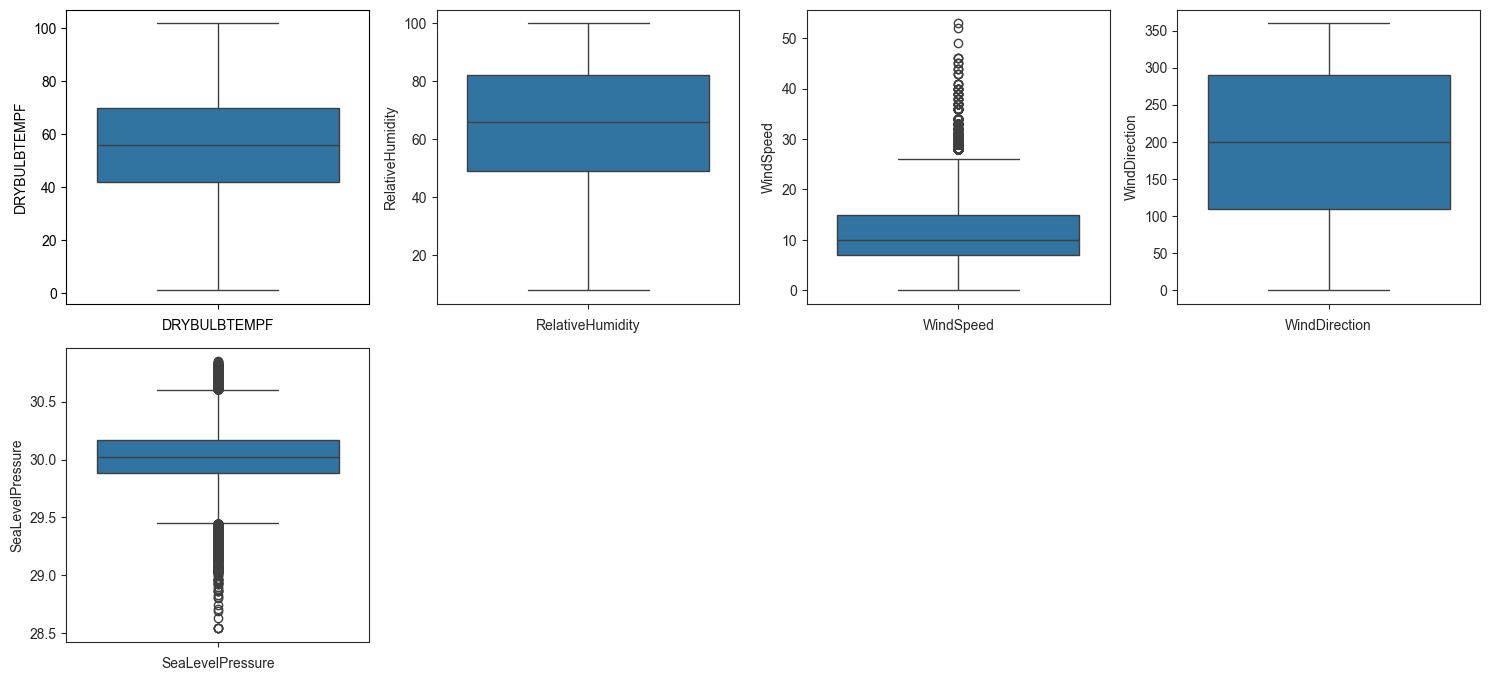

In [17]:
plt.figure(figsize=(15,10))

for i in range(len(cont_fe)):
    plt.subplot(3,4,i+1)
    sns.set_style('ticks')
    sns.boxplot(df[cont_fe[i]])
    plt.xlabel(cont_fe[i])
    plt.tight_layout()

**report**
- We can see, there are no such outliers in `DRYBULBTEMPF`, `RelativeHumidity`, and `WindDirection` Columns
- But there are outliers in  `WindSpeed`, ` SeaLevelPressure` following columns 


In [18]:
for col in continuous_feature:
    df[col] = df[col].astype(float)

In [19]:
df.dtypes

VISIBILITY          float64
DRYBULBTEMPF        float64
RelativeHumidity    float64
WindSpeed           float64
WindDirection       float64
SeaLevelPressure    float64
dtype: object

In [20]:
def detect_outliers(col):
    # Finding the IQR
    percentile25 = df[col].quantile(0.25)
    percentile75 = df[col].quantile(0.75)
    print('\n ####', col , '####')
    print("percentile25",percentile25)
    print("percentile75",percentile75)
    iqr = percentile75 - percentile25
    upper_limit = percentile75 + 1.5 * iqr
    lower_limit = percentile25 - 1.5 * iqr
    print("Upper limit",upper_limit)
    print("Lower limit",lower_limit)
    df.loc[(df[col]>upper_limit), col]= upper_limit
    df.loc[(df[col]<lower_limit), col]= lower_limit    
    return df

for col in continuous_feature:
    detect_outliers(col)




 #### DRYBULBTEMPF ####
percentile25 42.0
percentile75 70.0
Upper limit 112.0
Lower limit 0.0

 #### RelativeHumidity ####
percentile25 49.0
percentile75 82.0
Upper limit 131.5
Lower limit -0.5

 #### WindSpeed ####
percentile25 7.0
percentile75 15.0
Upper limit 27.0
Lower limit -5.0

 #### WindDirection ####
percentile25 110.0
percentile75 290.0
Upper limit 560.0
Lower limit -160.0

 #### SeaLevelPressure ####
percentile25 29.88
percentile75 30.17
Upper limit 30.605000000000004
Lower limit 29.444999999999993


In [21]:
cont_feat=continuous_feature.copy()

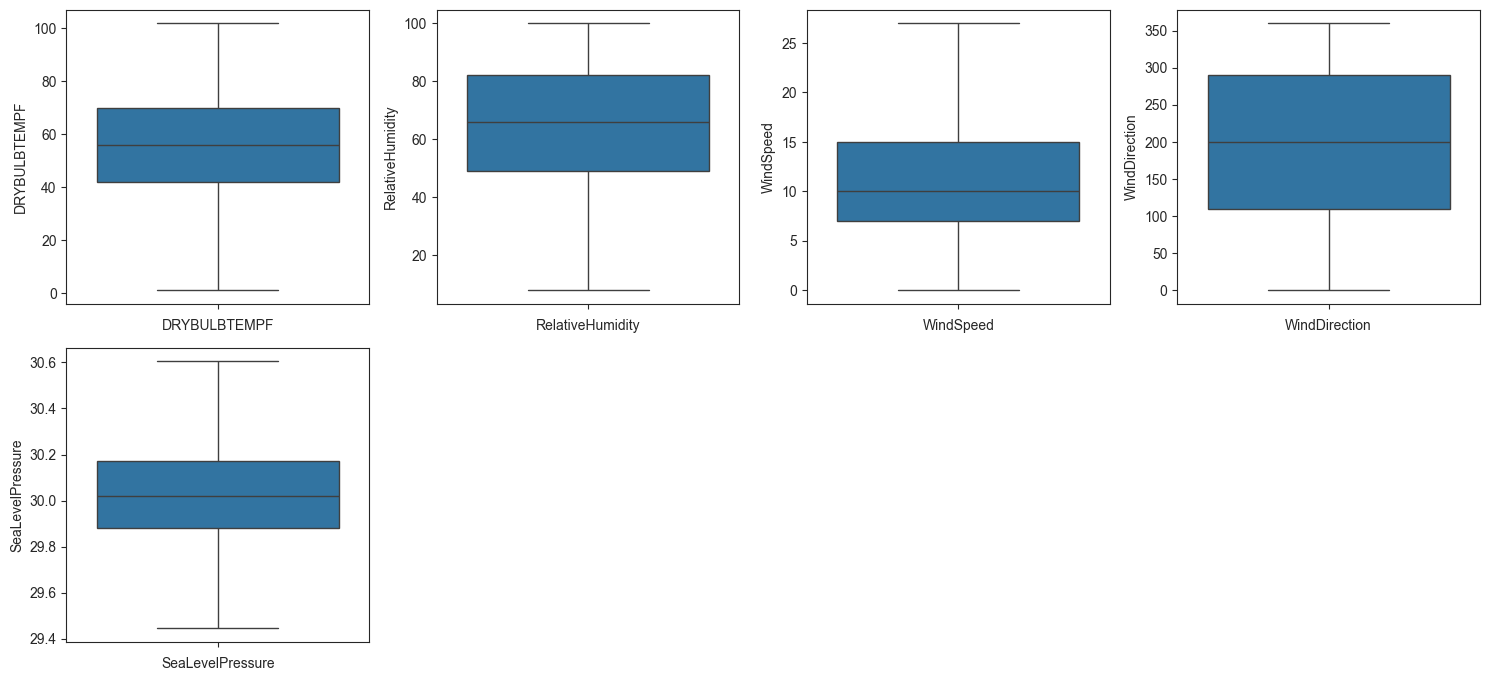

In [22]:
plt.figure(figsize=(15,10))

for i in range(len(cont_feat)):
    plt.subplot(3,4,i+1)
    sns.set_style('ticks')
    sns.boxplot(df[cont_feat[i]])
    plt.xlabel(cont_feat[i])
    plt.tight_layout()

### Model Building ( Clustering )

We know that our dataset it unsupervised, that means we don't have such target column. So we will be using clustering algorithms first to cluster the dataset and create target levels out of it. 

- What is Clustering?
> Using a clustering algorithm means you're going to give the algorithm a lot of input data with no labels and let it find any groupings in the data it can. Those groupings are called clusters. A cluster is a group of data points that are similar to each other based on their relation to surrounding data points.

Here for Clustering Problem statement, 4 Algorithms are used.

- K-Means Clustering
- Agglomerative Clustering
- Gaussian Mixture
- DBSCAN


- **What is silhouette score**

The silhouette value is a measure of how similar an object is to its o**wn cluster (cohesion) compared to other clusters (separation). The silhouette ranges from −1 to +1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

#### Elbow Method to find best Clusters for K-Means
- In the Elbow method, we are actually varying the number of clusters ( K ) from 1 – 10. For each value of K, we are calculating WCSS ( Within-Cluster Sum of Square ). WCSS is the sum of squared distance between each point and the centroid in a cluster. When we plot the WCSS with the K value, the plot looks like an Elbow. As the number of clusters increases, the WCSS value will start to decrease. WCSS value is largest when K = 1. When we analyze the graph we can see that the graph will rapidly change at a point and thus creating an elbow shape.

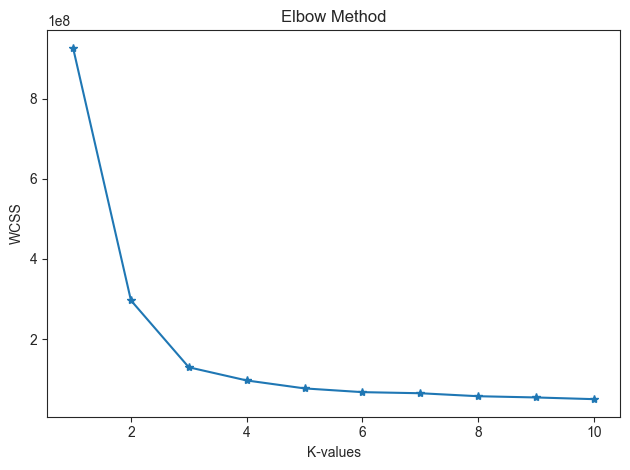

In [23]:
from sklearn.cluster import KMeans

wcss={}
for i in range(1,11):
    km=KMeans(n_clusters=i)
    km.fit(df)
    wcss[i]=km.inertia_

plt.plot(range(1,11),wcss.values(),marker='*')
plt.xlabel('K-values')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.tight_layout()

### Apply Kmeans Clustering with 3 clusters

In [24]:
from kneed import KneeLocator
from sklearn.cluster import KMeans

def select_no_of_clusters(dataframe):
    wcss = []
    try:
        for i in range(1, 11):
            km = KMeans(n_clusters=i, init='k-means++', random_state=42)
            km.fit(dataframe)
            wcss.append(km.inertia_)

        kn = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
        return kn.knee

    except Exception as e:
        print(e)

In [25]:
no_of_cluster=select_no_of_clusters(df)
print("The no of cluster is",no_of_cluster)

The no of cluster is 3


In [26]:
kmeans=KMeans(no_of_cluster)
kmeans.fit(df)
labels=kmeans.predict(df)

In [27]:
df['Cluster']=labels

In [28]:
df

,VISIBILITY,DRYBULBTEMPF,RelativeHumidity,WindSpeed,WindDirection,SeaLevelPressure,Cluster
0,6.0,33.0,92.0,0.0,0.0,29.99,0
1,6.0,33.0,96.0,0.0,0.0,29.99,0
2,5.0,33.0,96.0,0.0,0.0,29.99,0
3,5.0,33.0,96.0,0.0,0.0,29.97,0
4,5.0,33.0,92.0,0.0,0.0,29.96,0
...,...,...,...,...,...,...,...
75078,10.0,76.0,88.0,3.0,230.0,30.02,2
75079,4.0,69.0,100.0,13.0,40.0,30.01,0
75080,10.0,71.0,96.0,0.0,0.0,30.04,0
75081,10.0,72.0,94.0,5.0,50.0,30.02,0


In [29]:
df['Cluster'].value_counts()

Cluster
2    28618
1    26617
0    19848
Name: count, dtype: int64

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

train_set,test_set=train_test_split(df,test_size=0.2)

X_train=train_set.drop(columns=['VISIBILITY','Cluster'])
y_train=train_set[['VISIBILITY']]
X_test=test_set.drop(columns=['VISIBILITY','Cluster'])
y_test=test_set[['VISIBILITY']]

processor=StandardScaler()
X_train=processor.fit_transform(X_train)
X_test=processor.transform(X_test)

In [31]:
X_train.shape,y_train.shape

((60066, 5), (60066, 1))

In [32]:
#pip install dask[distributed]


In [33]:
#

In [ ]:
#


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import dask.distributed as distributed

cluster=distributed.LocalCluster()
client=distributed.Client(cluster)
client.restart()

from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

models={}

models['linear_regression']=LinearRegression()
models['Ridge']=Ridge()
models['Lasso']=Lasso()
models['ElasticNet']=ElasticNet()
models['XGBR']=XGBRegressor()
models['DT']=DecisionTreeRegressor()
models['RandomForestR']=RandomForestRegressor()

def select_best_model(model=models,x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test):
    models_details=[]
    for model_name,model in models.items():
        model_detail={}
        model.fit(x_train,y_train)
        y_pred=model.predict(x_test)
        model_score=r2_score(y_test,y_pred)
        model_detail['model_name']=model_name
        model_detail['model_score']=model_score
        print("%s the model is trained" % model_name)

        models_details.append(model_detail)
    return models_details

models_details=select_best_model()
models_details

2026-03-14 11:37:05,124 - distributed.nanny - WARNING - Restarting worker
2026-03-14 11:37:05,132 - distributed.nanny - WARNING - Restarting worker
2026-03-14 11:37:05,141 - distributed.nanny - WARNING - Restarting worker
2026-03-14 11:37:05,149 - distributed.nanny - WARNING - Restarting worker


linear_regression the model is trained
Ridge the model is trained
Lasso the model is trained
ElasticNet the model is trained
XGBR the model is trained
DT the model is trained
RandomForestR the model is trained


[{'model_name': 'linear_regression', 'model_score': 0.2536323249336474},
 {'model_name': 'Ridge', 'model_score': 0.2536321586591652},
 {'model_name': 'Lasso', 'model_score': 0.010297359410483375},
 {'model_name': 'ElasticNet', 'model_score': 0.12160973174913381},
 {'model_name': 'XGBR', 'model_score': 0.5978208184242249},
 {'model_name': 'DT', 'model_score': 0.2688162646135811},
 {'model_name': 'RandomForestR', 'model_score': 0.6138321356373447}]

2026-03-14 13:34:12,161 - distributed.scheduler - WARNING - Worker failed to heartbeat for 3439s; attempting restart: <WorkerState 'tcp://127.0.0.1:54041', name: 2, status: running, memory: 0, processing: 0>
2026-03-14 13:34:12,173 - distributed.scheduler - WARNING - Worker failed to heartbeat for 3439s; attempting restart: <WorkerState 'tcp://127.0.0.1:54044', name: 3, status: running, memory: 0, processing: 0>
2026-03-14 13:34:12,174 - distributed.scheduler - WARNING - Worker failed to heartbeat for 3439s; attempting restart: <WorkerState 'tcp://127.0.0.1:54047', name: 0, status: running, memory: 0, processing: 0>
2026-03-14 13:34:12,176 - distributed.scheduler - WARNING - Worker failed to heartbeat for 3439s; attempting restart: <WorkerState 'tcp://127.0.0.1:54050', name: 1, status: running, memory: 0, processing: 0>


# Read model.yml file to get randomforest params

In [36]:
import sys
import os

sys.path.append(os.path.abspath(".."))      # goes to src
sys.path.append(os.path.abspath("../.."))   # goes to project root

In [37]:
from src.utils.main_utils import MainUtils

import os
os.chdir("..")
utils = MainUtils()
rf_grid = utils.read_yaml_file("config/model.yaml")['model_selection']['model']['Random Forest Regression']['search_param_grid']

In [38]:
rf_grid

{'n_estimators': [50, 100, 130],
 'max_depth': [10, 20, 30],
 'min_samples_split': [2, 6, 10],
 'bootstrap': [True, False]}

# let's start CV operation on top of randomforest

In [39]:
from sklearn.model_selection import GridSearchCV
import joblib

with joblib.parallel_backend('dask'):
    model_grid = GridSearchCV(
        RandomForestRegressor(), rf_grid, 
        cv = 2,
        n_jobs = -1 ,
        verbose=3 )
    model_grid.fit(X_train,y_train)


Fitting 2 folds for each of 54 candidates, totalling 108 fits


## Best params for randomforest

In [40]:
best_params = model_grid.best_params_
rf_model = RandomForestRegressor(**best_params)

In [41]:
def train_model():
    models={}
    preprocessor = StandardScaler()
    list_of_clusters:list = train_set['Cluster'].unique()
    model = []
    for cluster_no in list_of_clusters:
        train_set_cluster = train_set[train_set['Cluster'] == cluster_no]
        test_set_cluster = test_set[test_set['Cluster'] == cluster_no]

        X_train = train_set_cluster.drop(columns = ['VISIBILITY', 'Cluster'])
        X_test = test_set_cluster.drop(columns = ['VISIBILITY', 'Cluster'])

        X_train = preprocessor.fit_transform(X_train)
        X_test = preprocessor.transform(X_test)

        y_train = train_set_cluster[['VISIBILITY']]
        y_test = test_set_cluster[['VISIBILITY']]

        print(f"Training on cluster_no {cluster_no}")
        model = rf_model
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        score = r2_score(y_test,y_pred)
        print(f"score for cluster no {cluster_no} is: {score}")
        
        models[f"model_{cluster_no}"] = model
    return models

        #print(X_train, y_train, X_test, y_test)

models=train_model()

Training on cluster_no 2
score for cluster no 2 is: 0.5749108295228635
Training on cluster_no 0
score for cluster no 0 is: 0.6153294116690629
Training on cluster_no 1
score for cluster no 1 is: 0.633973739013119


In [42]:
models

{'model_2': RandomForestRegressor(max_depth=30, min_samples_split=10, n_estimators=130),
 'model_0': RandomForestRegressor(max_depth=30, min_samples_split=10, n_estimators=130),
 'model_1': RandomForestRegressor(max_depth=30, min_samples_split=10, n_estimators=130)}

In [43]:
import pickle
pickle.dump(rf_model,open('model.pkl','wb'))

loaded_model=pickle.load(open('model.pkl','rb'))

In [44]:
loaded_model

,n_estimators,130
,criterion,'squared_error'
,max_depth,30
,min_samples_split,10
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


2026-03-14 13:34:13,474 - distributed.nanny - WARNING - Restarting worker
2026-03-14 13:34:13,499 - distributed.nanny - WARNING - Restarting worker
2026-03-14 13:34:13,526 - distributed.nanny - WARNING - Restarting worker
2026-03-14 13:34:13,563 - distributed.nanny - WARNING - Restarting worker
